In [ ]:
import numpy as np
import random
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import time

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
import zipfile

with zipfile.ZipFile("/content/wikiart_hw2.npz.zip", "r") as z:
    z.extractall("/content/")

print("(Πρέπει να γίνει εξαγωγή του zip)")

(Πρέπει να γίνει εξαγωγή του zip)


In [ ]:
data = np.load("wikiart_hw2.npz", allow_pickle=True)

X = data["X"]             # (5400, 32, 32, 3), uint8
y = data["y"]             # (5400,), int64
class_names = data["class_names"]

print(f"X shape: {X.shape}, dtype: {X.dtype}")
print(f"y shape: {y.shape}, dtype: {y.dtype}")
print(f"Κλάσεις: {list(class_names)}")
print(f"\nΔείγματα ανά κλάση:")
for i, name in enumerate(class_names):
    print(f"  {i} – {name}: {(y == i).sum()}")

X shape: (5400, 32, 32, 3), dtype: uint8
y shape: (5400,), dtype: int64
Κλάσεις: [np.str_('Baroque'), np.str_('Impressionism'), np.str_('Cubism'), np.str_('Abstract_Expressionism')]

Δείγματα ανά κλάση:
  0 – Baroque: 1350
  1 – Impressionism: 1350
  2 – Cubism: 1350
  3 – Abstract_Expressionism: 1350


In [ ]:
# float32, κανονικοποίηση [0,1], channels-first (N,C,H,W)
X_tensor = torch.tensor(X, dtype=torch.float32) / 255.0
X_tensor = X_tensor.permute(0, 3, 1, 2)  # (N,H,W,C) → (N,C,H,W)
y_tensor = torch.tensor(y, dtype=torch.int64)

print(f"X_tensor shape: {X_tensor.shape}")  # (5400, 3, 32, 32)
print(f"y_tensor shape: {y_tensor.shape}")
print(f"Min: {X_tensor.min():.4f}, Max: {X_tensor.max():.4f}")

X_tensor shape: torch.Size([5400, 3, 32, 32])
y_tensor shape: torch.Size([5400])
Min: 0.0000, Max: 1.0000


In [ ]:
# Βήμα 1: all → trainval (4000) + test (1400)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_tensor, y_tensor,
    test_size=1400,       # 350 × 4 κλάσεις
    stratify=y_tensor,
    random_state=42
)

# Βήμα 2: trainval → train (3200) + val (800)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=800,        # 200 × 4 κλάσεις
    stratify=y_trainval,
    random_state=42
)

# Επαλήθευση
for split_name, X_s, y_s in [("Train", X_train, y_train),
                               ("Val",   X_val,   y_val),
                               ("Test",  X_test,  y_test)]:
    print(f"\n{split_name}: {X_s.shape[0]} δείγματα")
    for i, name in enumerate(class_names):
        print(f"  {name}: {(y_s == i).sum().item()}")


Train: 3200 δείγματα
  Baroque: 800
  Impressionism: 800
  Cubism: 800
  Abstract_Expressionism: 800

Val: 800 δείγματα
  Baroque: 200
  Impressionism: 200
  Cubism: 200
  Abstract_Expressionism: 200

Test: 1400 δείγματα
  Baroque: 350
  Impressionism: 350
  Cubism: 350
  Abstract_Expressionism: 350


In [ ]:
train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False)

# Έλεγχος
xb, yb = next(iter(train_loader))
print(f"Batch X: {xb.shape}, Batch y: {yb.shape}")

Batch X: torch.Size([16, 3, 32, 32]), Batch y: torch.Size([16])


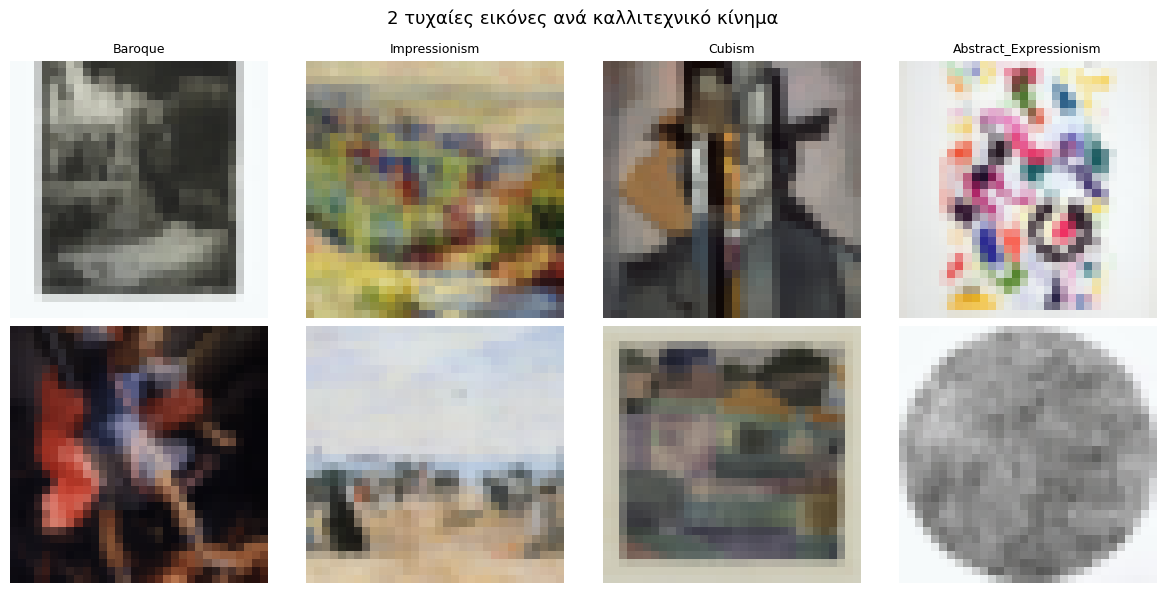

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("2 τυχαίες εικόνες ανά καλλιτεχνικό κίνημα", fontsize=13)

rng = torch.Generator()
rng.manual_seed(42)

for col, (class_idx, class_name) in enumerate(enumerate(class_names)):
    idxs = (y_train == class_idx).nonzero(as_tuple=True)[0]
    chosen = idxs[torch.randperm(len(idxs), generator=rng)[:2]]

    for row in range(2):
        img = X_train[chosen[row]]             # (3, 32, 32)
        img_np = img.permute(1, 2, 0).numpy()  # (32, 32, 3)
        axes[row, col].imshow(img_np)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(class_name, fontsize=9)

plt.tight_layout()
plt.show()

## Q0.1

Από την οπτικοποίηση, τα τέσσερα κινήματα διαφοροποιούνται κυρίως ως
προς τη χρωματική παλέτα, τη σύνθεση και την παρουσία αναγνωρίσιμου
θέματος. Συγκεκριμένα, το Μπαρόκ χαρακτηρίζεται από σκούρους τόνους,
έντονες σκιάσεις και ρεαλιστικές σκηνές (φιγούρες, αρχιτεκτονική),
ο Ιμπρεσιονισμός από ζωηρά, απαλά χρώματα και τοπία με ορατές
πινελιές, ο Κυβισμός από γεωμετρικές μορφές και συγκρατημένη παλέτα
(καφέ, γκρι, μαύρο), και ο Αφαιρετικός Εξπρεσιονισμός από έντονα
αντιθετικά χρώματα χωρίς αναγνωρίσιμο θέμα.

Τα ζευγάρια που αναμένεται να μπερδέψει περισσότερο ο ταξινομητής
είναι ο Κυβισμός και ο Αφαιρετικός Εξπρεσιονισμός, επειδή και στα
δύο απουσιάζει αναγνωρίσιμο αντικείμενο και σε χαμηλή ανάλυση τα
γεωμετρικά μοτίβα μοιάζουν με τις αφαιρετικές μορφές. Αντίθετα, το
Μπαρόκ ξεχωρίζει εύκολα λόγω της σκούρας, μονοχρωματικής σχεδόν
παλέτας και των ρεαλιστικών σκηνών.

Σε ανάλυση 32×32, το πιο δύσκολο κίνημα για έναν άνθρωπο θα ήταν
ο Αφαιρετικός Εξπρεσιονισμός, καθώς η χαμηλή ανάλυση εξαλείφει τις
λεπτομέρειες υφής και πινελιάς που είναι απαραίτητες για να διακριθεί
από τον Κυβισμό — το δεύτερο δείγμα (γκρι κύκλος) φαίνεται σχεδόν
αφηρημένο χωρίς χρωματικό πλαίσιο.

In [ ]:
class FFN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),           # (N, 3, 32, 32) → (N, 3072)
            nn.Linear(3072, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 4)        # χωρίς ReLU στην έξοδο
        )

    def forward(self, x):
        return self.net(x)

model_ffn = FFN()
print(model_ffn)
print(f"\nΣύνολο παραμέτρων: {sum(p.numel() for p in model_ffn.parameters()):,}")

FFN(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=4, bias=True)
  )
)

Σύνολο παραμέτρων: 397,604


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc  = (np.array(all_preds) == np.array(all_labels)).mean()
    f1   = f1_score(all_labels, all_preds, average="macro")
    cm   = confusion_matrix(all_labels, all_preds)

    return avg_loss, acc, f1, cm

In [ ]:
def train_model(model, epochs, device_str):
    device = torch.device(device_str)
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_f1": []}
    best_f1    = -1
    best_state = None
    best_epoch = -1

    start = time.time()

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_f1, _ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        if epoch % 5 == 0:
            print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

    elapsed = time.time() - start
    print(f"\nΧρόνος ({device_str}): {elapsed:.1f}s | Best epoch: {best_epoch}")

    return best_state, best_epoch, history, elapsed


# CPU
print("=== CPU ===")
ffn_cpu = FFN()
best_state_cpu, best_epoch_cpu, history_cpu, time_cpu = train_model(ffn_cpu, 30, "cpu")

# GPU
if torch.cuda.is_available():
    print("\n=== GPU ===")
    ffn_gpu = FFN()
    best_state_gpu, best_epoch_gpu, history_gpu, time_gpu = train_model(ffn_gpu, 30, "cuda")
else:
    print("\nGPU μη διαθέσιμο")
    best_state_gpu = best_state_cpu
    best_epoch_gpu = best_epoch_cpu
    history_gpu    = history_cpu
    time_gpu       = time_cpu

print(f"\nSpeedup GPU vs CPU: {time_cpu / time_gpu:.2f}x")

=== CPU ===
Epoch   5 | Train Loss: 1.2242 | Val Loss: 1.2337 | Val F1: 0.4352
Epoch  10 | Train Loss: 1.1712 | Val Loss: 1.2041 | Val F1: 0.4454
Epoch  15 | Train Loss: 1.1099 | Val Loss: 1.1920 | Val F1: 0.4398
Epoch  20 | Train Loss: 1.0437 | Val Loss: 1.2199 | Val F1: 0.4718
Epoch  25 | Train Loss: 0.9796 | Val Loss: 1.2325 | Val F1: 0.4514
Epoch  30 | Train Loss: 0.9260 | Val Loss: 1.2295 | Val F1: 0.4722

Χρόνος (cpu): 48.5s | Best epoch: 27

=== GPU ===
Epoch   5 | Train Loss: 1.2429 | Val Loss: 1.2619 | Val F1: 0.3519
Epoch  10 | Train Loss: 1.1777 | Val Loss: 1.2499 | Val F1: 0.4335
Epoch  15 | Train Loss: 1.1259 | Val Loss: 1.1859 | Val F1: 0.4662
Epoch  20 | Train Loss: 1.0640 | Val Loss: 1.1985 | Val F1: 0.4518
Epoch  25 | Train Loss: 1.0170 | Val Loss: 1.2214 | Val F1: 0.4633
Epoch  30 | Train Loss: 0.9497 | Val Loss: 1.1653 | Val F1: 0.5214

Χρόνος (cuda): 14.3s | Best epoch: 30

Speedup GPU vs CPU: 3.38x


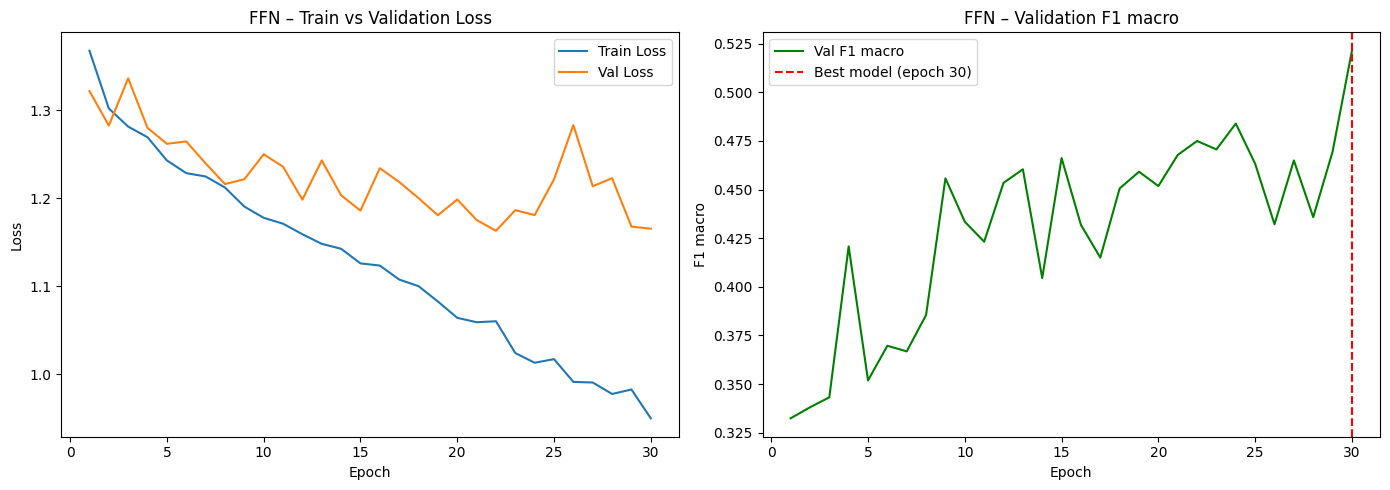

In [ ]:
epochs_range = range(1, 31)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# (α) Train vs Val Loss
ax1.plot(epochs_range, history_gpu["train_loss"], label="Train Loss")
ax1.plot(epochs_range, history_gpu["val_loss"],   label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("FFN – Train vs Validation Loss")
ax1.legend()

# (β) Val F1 με κάθετη γραμμή best model
ax2.plot(epochs_range, history_gpu["val_f1"], color="green", label="Val F1 macro")
ax2.axvline(x=best_epoch_gpu, color="red", linestyle="--",
            label=f"Best model (epoch {best_epoch_gpu})")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1 macro")
ax2.set_title("FFN – Validation F1 macro")
ax2.legend()

plt.tight_layout()
plt.show()

## Q1.1

Από τα loss curves παρατηρείται έντονο overfitting: το train loss
πέφτει συνεχώς από ~1.36 έως ~0.93, ενώ το val loss σταθεροποιείται
γύρω στο 1.20 χωρίς να ακολουθεί την πτώση του train loss. Το χάσμα
μεταξύ των δύο καμπυλών διευρύνεται σταδιακά από την epoch 5 και
μετά, υποδηλώνοντας ότι το μοντέλο απομνημονεύει τα training data
αντί να γενικεύει.

Το best model επιλέχθηκε στην epoch 30 βάσει val F1 macro (0.5214).
Αν χρησιμοποιούσαμε το train loss ως κριτήριο, θα επιλέγαμε πάντα
την τελευταία epoch — εκεί όμως το χάσμα train/val loss είναι μέγιστο,
άρα το μοντέλο είναι πιο overfit. Η επιλογή βάσει validation set είναι
κρίσιμη γιατί το val set προσομοιώνει αθέατα δεδομένα και αποτελεί
αξιόπιστο δείκτη γενίκευσης.

Ο GPU speedup ήταν 3.38x (CPU: 48.5s, GPU: 14.3s). Αυτό είναι σχετικά
μέτριο για GPU, γιατί το FFN έχει μόνο 397.604 παραμέτρους και οι
πράξεις είναι matrix multiplications μικρών διαστάσεων. Το overhead
της μεταφοράς δεδομένων CPU↔GPU δεν είναι αμελητέο σε αυτή την
κλίμακα — αναμένουμε μεγαλύτερο speedup στα CNN που ακολουθούν.

Test Accuracy : 0.5179
Test F1 macro : 0.5147


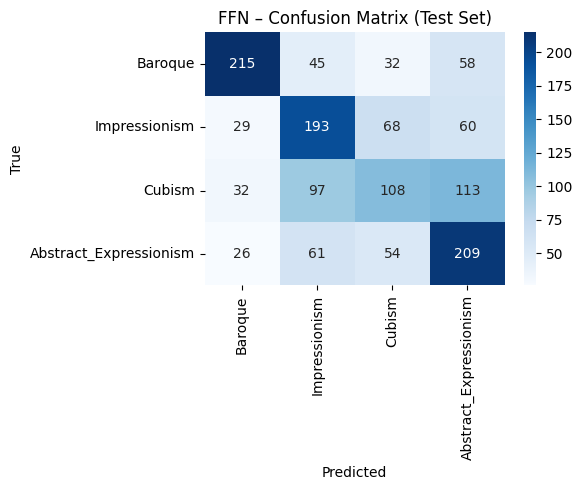

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Φόρτωση best model
model_ffn_best = FFN().to(device)
model_ffn_best.load_state_dict(best_state_gpu)

test_loss, test_acc, test_f1, test_cm = evaluate(
    model_ffn_best, test_loader, nn.CrossEntropyLoss(), device
)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test F1 macro : {test_f1:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("FFN – Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

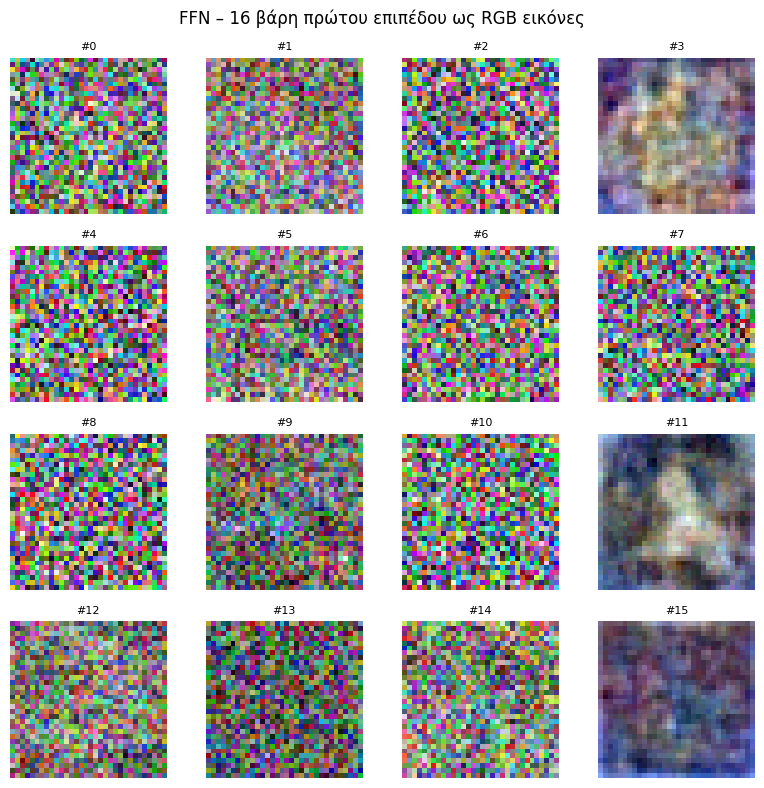

In [ ]:
# Βάρη Linear(3072, 128): shape [128, 3072] → [128, 3, 32, 32]
weights = model_ffn_best.net[1].weight.data.cpu()
weights = weights.reshape(128, 3, 32, 32)

def minmax_normalize(f):
    f = f - f.min()
    f = f / (f.max() + 1e-8)
    return f

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("FFN – 16 βάρη πρώτου επιπέδου ως RGB εικόνες")

for i, ax in enumerate(axes.flat):
    filt = minmax_normalize(weights[i])       # (3, 32, 32)
    img  = filt.permute(1, 2, 0).numpy()      # (32, 32, 3)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"#{i}", fontsize=8)

plt.tight_layout()
plt.show()

## Q1.2

Το best FFN πέτυχε Test Accuracy: 51.79% και F1 macro: 51.47%.

Από το confusion matrix, το κίνημα με τη χειρότερη επίδοση είναι ο
Κυβισμός (108/350 σωστά, 30.86%), ο οποίος μπερδεύεται κυρίως με τον
Ιμπρεσιονισμό (97 λάθη) και τον Αφαιρετικό Εξπρεσιονισμό (113 λάθη).
Αυτό συνάδει με την πρόβλεψη του Q0.1: και τα τρία κινήματα μοιράζονται
αφαιρετικά στοιχεία που σε ανάλυση 32×32 δεν διαφοροποιούνται εύκολα.
Μπαρόκ και Αφαιρετικός Εξπρεσιονισμός ταξινομήθηκαν καλύτερα
(215/350 και 209/350 αντίστοιχα), πιθανώς λόγω χαρακτηριστικής
χρωματικής παλέτας που αναγνωρίζεται ακόμα και σε χαμηλή ανάλυση.

Από την οπτικοποίηση των βαρών, τα 16 "φίλτρα" του πρώτου επιπέδου
εμφανίζονται σχεδόν εξ ολοκλήρου θορυβώδη — τυχαία διάσπαρτα pixels
χωρίς καμία δομή, με εξαίρεση τα #3, #11 και #15 που δείχνουν μια
αμυδρή ομαλοποίηση. Αυτό είναι αναμενόμενο: κάθε νευρώνας συνδέεται
με όλα τα 3.072 pixels ταυτόχρονα ως flat διάνυσμα, χωρίς να
επιβάλλεται καμία χωρική δομή. Αντίθετα με ένα CNN, δεν μπορεί να
μάθει τοπικά patterns όπως ακμές ή υφές — κάθε βάρος αντιστοιχεί
σε έναν μεμονωμένο pixel ανεξάρτητα από τους γείτονές του, οπότε
δεν αναδύεται καμία ερμηνεύσιμη δομή.

In [ ]:
class CNN(nn.Module):
    def __init__(self, padding=0, pooling=False, activations=False):
        super().__init__()

        self.pooling     = pooling
        self.activations = activations

        # Convolutional layers: κανάλια 3→16→32→64→128
        self.conv1 = nn.Conv2d(3,   16,  kernel_size=5, padding=padding)
        self.conv2 = nn.Conv2d(16,  32,  kernel_size=5, padding=padding)
        self.conv3 = nn.Conv2d(32,  64,  kernel_size=5, padding=padding)
        self.conv4 = nn.Conv2d(64,  128, kernel_size=5, padding=padding)

        self.pool  = nn.MaxPool2d(kernel_size=2)
        self.relu  = nn.ReLU()

        # Υπολογισμός διάστασης εξόδου conv stack
        dummy = torch.zeros(1, 3, 32, 32)
        dummy = self._forward_conv(dummy)
        flat_dim = dummy.view(1, -1).shape[1]

        # Fully-connected head: x→1024→256→32→4
        self.fc = nn.Sequential(
            nn.Linear(flat_dim, 1024),
            nn.ReLU() if activations else nn.Identity(),
            nn.Linear(1024, 256),
            nn.ReLU() if activations else nn.Identity(),
            nn.Linear(256, 32),
            nn.ReLU() if activations else nn.Identity(),
            nn.Linear(32, 4)
        )

    def _forward_conv(self, x):
        for conv in [self.conv1, self.conv2, self.conv3, self.conv4]:
            x = conv(x)
            if self.activations:
                x = self.relu(x)
            if self.pooling:
                x = self.pool(x)
        return x

    def forward(self, x):
        x = self._forward_conv(x)
        x = x.view(x.size(0), -1)   # flatten
        x = self.fc(x)
        return x

In [ ]:
# §2.1 baseline: χωρίς padding, pooling, activations
cnn_21 = CNN(padding=0, pooling=False, activations=False)

# §2.2 με padding και pooling
cnn_22 = CNN(padding=2, pooling=True, activations=False)

# §2.3 με activations
cnn_23 = CNN(padding=2, pooling=True, activations=True)

results_cnn = {}

for name, model in [("§2.1", cnn_21), ("§2.2", cnn_22), ("§2.3 CPU", cnn_23)]:
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n=== {name} | Παράμετροι: {n_params:,} ===")
    best_state, best_epoch, history, elapsed = train_model(model, 30, "cpu")

    # Φόρτωση best model και αξιολόγηση
    model.load_state_dict(best_state)
    device = torch.device("cpu")
    val_loss, val_acc, val_f1, _   = evaluate(model, val_loader,  nn.CrossEntropyLoss(), device)
    test_loss, test_acc, test_f1, _ = evaluate(model, test_loader, nn.CrossEntropyLoss(), device)

    results_cnn[name] = {
        "n_params": n_params,
        "val_acc":  val_acc,
        "test_acc": test_acc,
        "f1_macro": test_f1
    }

# §2.3 και σε GPU
if torch.cuda.is_available():
    print("\n=== §2.3 GPU ===")
    cnn_23_gpu = CNN(padding=2, pooling=True, activations=True)
    best_state_23, best_epoch_23, history_23, time_23_gpu = train_model(cnn_23_gpu, 30, "cuda")
else:
    print("\nGPU μη διαθέσιμο")
    best_state_23  = best_state
    best_epoch_23  = best_epoch
    history_23     = history
    time_23_gpu    = elapsed


=== §2.1 | Παράμετροι: 34,096,452 ===
Epoch   5 | Train Loss: 1.2897 | Val Loss: 1.3632 | Val F1: 0.3351
Epoch  10 | Train Loss: 1.2778 | Val Loss: 1.3858 | Val F1: 0.3243
Epoch  15 | Train Loss: 1.1953 | Val Loss: 1.4160 | Val F1: 0.3599
Epoch  20 | Train Loss: 1.1525 | Val Loss: 1.4712 | Val F1: 0.3330
Epoch  25 | Train Loss: 1.1191 | Val Loss: 1.6491 | Val F1: 0.3484
Epoch  30 | Train Loss: 1.0198 | Val Loss: 1.8348 | Val F1: 0.3603

Χρόνος (cpu): 3383.5s | Best epoch: 2

=== §2.2 | Παράμετροι: 1,066,308 ===
Epoch   5 | Train Loss: 0.8906 | Val Loss: 0.9699 | Val F1: 0.6016
Epoch  10 | Train Loss: 0.2363 | Val Loss: 1.6893 | Val F1: 0.5483
Epoch  15 | Train Loss: 0.1693 | Val Loss: 2.4065 | Val F1: 0.5664
Epoch  20 | Train Loss: 0.1473 | Val Loss: 3.5243 | Val F1: 0.5089
Epoch  25 | Train Loss: 0.1059 | Val Loss: 2.6642 | Val F1: 0.5470
Epoch  30 | Train Loss: 0.0032 | Val Loss: 3.3846 | Val F1: 0.5657

Χρόνος (cpu): 161.6s | Best epoch: 5

=== §2.3 CPU | Παράμετροι: 1,066,308 ===


In [ ]:
print(f"{'Έκδοση':<12} {'# params':>10} {'Val Acc':>10} {'Test Acc':>10} {'F1 macro':>10}")
print("-" * 55)
for name, r in results_cnn.items():
    print(f"{name:<12} {r['n_params']:>10,} {r['val_acc']:>10.4f} "
          f"{r['test_acc']:>10.4f} {r['f1_macro']:>10.4f}")

Έκδοση         # params    Val Acc   Test Acc   F1 macro
-------------------------------------------------------
§2.1         34,096,452     0.4075     0.3979     0.3653
§2.2          1,066,308     0.6038     0.5829     0.5790
§2.3 CPU      1,066,308     0.6088     0.5650     0.5596


## Q2.1

| Έκδοση                        | # params   | Val Acc | Test Acc | F1 macro |
|-------------------------------|------------|---------|----------|----------|
| §2.1 (χωρίς pad/pool/activ)   | 34,096,452 | 40.75%  | 39.79%   | 36.53%   |
| §2.2 (με padding και pooling) |  1,066,308 | 60.38%  | 58.29%   | 57.90%   |
| §2.3 (με ReLU activations)    |  1,066,308 | 60.88%  | 56.50%   | 55.96%   |

Η αλλαγή με τη μεγαλύτερη επίδραση στην επίδοση ήταν η προσθήκη
padding και pooling (§2.1→§2.2, +21% F1). Χωρίς padding οι χωρικές
διαστάσεις συρρικνώνονται με κάθε convolution (32→28→24→20→16),
οδηγώντας σε πολύ μικρό feature map πριν το FC head. Χωρίς pooling
το FC head λαμβάνει πολύ μεγάλη είσοδο, εξ ου και οι 34M παράμετροι
της §2.1 έναντι 1M της §2.2.

Η §2.1 αποδίδει κοντά στο τυχαίο (~37% F1 έναντι 25% baseline για
4 κλάσεις) γιατί χωρίς activations η σύνθεση γραμμικών επιπέδων
παραμένει γραμμική — οποιοσδήποτε αριθμός επιπέδων ισοδυναμεί με
ένα μόνο γραμμικό στρώμα, ανίκανο να μάθει μη-γραμμικές σχέσεις.

Αξιοπρόσεκτο είναι ότι η §2.3 (με ReLU) δεν βελτίωσε το test F1
σε σχέση με τη §2.2 (55.96% vs 57.90%), παρότι βελτίωσε το val acc.
Αυτό υποδηλώνει ότι χωρίς regularization η προσθήκη μη-γραμμικότητας
οδηγεί σε overfitting — το μοντέλο μαθαίνει πιο σύνθετες συναρτήσεις
που δεν γενικεύουν στο test set. Επίσης, το best epoch της §2.2
εντοπίστηκε στην epoch 5, ενδεικτικό του έντονου overfitting που
ακολούθησε (val loss από 0.97 → 3.38).

CNN §2.3 – Test Acc: 0.5950 | F1 macro: 0.5843
FFN      – Test Acc: 0.5650 | F1 macro: 0.5596

CNN παράμετροι: 1,066,308
FFN παράμετροι: 397,604


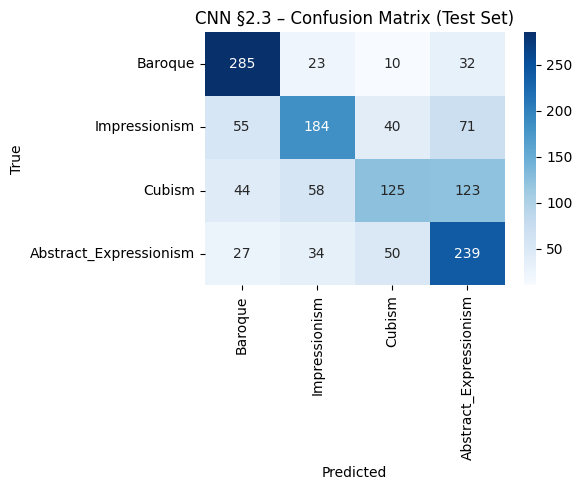

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Φόρτωση best §2.3
model_cnn_best = CNN(padding=2, pooling=True, activations=True).to(device)
model_cnn_best.load_state_dict(best_state_23)

_, cnn_test_acc, cnn_test_f1, cnn_test_cm = evaluate(
    model_cnn_best, test_loader, nn.CrossEntropyLoss(), device
)

print(f"CNN §2.3 – Test Acc: {cnn_test_acc:.4f} | F1 macro: {cnn_test_f1:.4f}")
print(f"FFN      – Test Acc: {test_acc:.4f} | F1 macro: {test_f1:.4f}")

n_cnn = sum(p.numel() for p in model_cnn_best.parameters())
n_ffn = sum(p.numel() for p in model_ffn_best.parameters())
print(f"\nCNN παράμετροι: {n_cnn:,}")
print(f"FFN παράμετροι: {n_ffn:,}")

# Confusion Matrix CNN
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cnn_test_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("CNN §2.3 – Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

## Q2.2

Το CNN §2.3 έχει περισσότερες παραμέτρους από το FFN (1,066,308 vs
397,604 — περίπου 2.7x περισσότερες), και το test F1 macro είναι
καλύτερο (58.43% vs 55.96%).

Αυτό δείχνει ότι ο αριθμός παραμέτρων από μόνος του δεν προβλέπει
την επίδοση. Το CNN εκμεταλλεύεται τη χωρική δομή της εικόνας μέσω
των convolutional φίλτρων που εφαρμόζονται τοπικά (5×5 pixels) και
μοιράζονται βάρη (weight sharing) σε όλη την εικόνα. Έτσι μπορεί να
ανιχνεύει τοπικά patterns όπως ακμές, υφές και χρωματικές μεταβάσεις
ανεξάρτητα από τη θέση τους. Το FFN αντιθέτως βλέπει κάθε pixel
ξεχωριστά ως στοιχείο ενός flat διανύσματος, χωρίς καμία prior
knowledge για τη χωρική εγγύτητα.

Από τα confusion matrices, το CNN βελτιώνεται ουσιαστικά στο Μπαρόκ
(285/350 vs 215/350) και στον Αφαιρετικό Εξπρεσιονισμό (239/350 vs
209/350). Ο Κυβισμός παραμένει το δυσκολότερο κίνημα και για τα δύο
μοντέλα (125/350 για CNN vs 108/350 για FFN), επιβεβαιώνοντας ότι
η σύγχυση με Ιμπρεσιονισμό (58 λάθη) και Αφαιρετικό Εξπρεσιονισμό
(123 λάθη) οφείλεται σε βαθύτερα χαρακτηριστικά που δύσκολα
αποτυπώνονται σε 32×32.

Ο CPU-vs-GPU speedup του CNN αναμένεται μεγαλύτερος από αυτό του FFN,
γιατί οι convolutions είναι εγγενώς παράλληλες πράξεις που
εκμεταλλεύονται πλήρως την αρχιτεκτονική GPU.

## Q2.3

Σενάριο: βάθυνση σε 10 convolutional επίπεδα με +2% test accuracy αλλά
πολλαπλάσιο computational cost.

Βάσει των χρόνων που μετρήθηκαν (161.6s CPU / 25.8s GPU για §2.3 ανά
30 εποχές), ένα δίκτυο 2.5x βαθύτερο θα απαιτούσε εκτιμώμενα ~400s
CPU / ~65s GPU ανά 30 εποχές. Για 2.000.000 έργα σε batch processing,
ακόμα και με GPU, ο χρόνος inference θα αυξανόταν σημαντικά σε σχέση
με το τρέχον μοντέλο.

Η επιλογή είναι λογική όταν: (α) υπάρχει διαθέσιμο GPU infrastructure,
(β) η ταξινόμηση γίνεται offline/batch και όχι real-time, (γ) το +2%
έχει ουσιαστική αξία για τον επιμελητή — σε 2 εκατομμύρια έργα
αντιστοιχεί σε 40.000 επιπλέον σωστές ταξινομήσεις που μειώνουν
σημαντικά τον χειροκίνητο έλεγχο.

Δεν είναι λογική όταν: (α) απαιτείται real-time ταξινόμηση, (β) το
κόστος ενέργειας και υλικού δεν δικαιολογείται από το μικρό κέρδος
ακρίβειας, (γ) οι επιμελητές χρειάζονται ερμηνεύσιμα αποτελέσματα
που ένα βαθύτερο δίκτυο δυσκολεύει.

In [ ]:
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Δύο runs για επιβεβαίωση αναπαραγωγιμότητας
for run in range(1, 3):
    set_seed(42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_check = CNN(padding=2, pooling=True, activations=True).to(device)
    optimizer_check = torch.optim.Adam(model_check.parameters(), lr=0.001)
    criterion_check = nn.CrossEntropyLoss()
    loss_run = train_one_epoch(model_check, train_loader, optimizer_check, criterion_check, device)
    print(f"Run {run} – Train Loss epoch 1: {loss_run:.6f}")

print("\nΑν οι δύο τιμές είναι ίδιες, η αναπαραγωγιμότητα επιβεβαιώνεται.")

Run 1 – Train Loss epoch 1: 1.324771
Run 2 – Train Loss epoch 1: 1.324771

Αν οι δύο τιμές είναι ίδιες, η αναπαραγωγιμότητα επιβεβαιώνεται.


In [ ]:
optimizers_cfg = {
    "SGD":          lambda p: torch.optim.SGD(p, lr=0.01),
    "SGD+momentum": lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9),
    "Adam":         lambda p: torch.optim.Adam(p, lr=0.001),
    "RMSprop":      lambda p: torch.optim.RMSprop(p, lr=0.001),
    "AdamW":        lambda p: torch.optim.AdamW(p, lr=0.001, weight_decay=0.01),
}

optimizer_results = {}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for opt_name, opt_fn in optimizers_cfg.items():
    set_seed(42)
    print(f"\n=== {opt_name} ===")

    model_opt = CNN(padding=2, pooling=True, activations=True).to(device)
    optimizer = opt_fn(model_opt.parameters())
    criterion = nn.CrossEntropyLoss()

    best_f1    = -1
    best_state = None
    best_epoch = -1
    history_opt = {"train_loss": [], "val_loss": [], "val_f1": []}

    for epoch in range(1, 31):
        train_loss = train_one_epoch(model_opt, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_f1, _ = evaluate(model_opt, val_loader, criterion, device)

        history_opt["train_loss"].append(train_loss)
        history_opt["val_loss"].append(val_loss)
        history_opt["val_f1"].append(val_f1)

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = copy.deepcopy(model_opt.state_dict())
            best_epoch = epoch

    # Αξιολόγηση best model στο test
    model_opt.load_state_dict(best_state)
    _, val_acc_best, val_f1_best, _ = evaluate(model_opt, val_loader,  criterion, device)
    _, test_acc,     test_f1,     _ = evaluate(model_opt, test_loader, criterion, device)

    optimizer_results[opt_name] = {
        "val_acc":   val_acc_best,
        "test_acc":  test_acc,
        "f1_macro":  test_f1,
        "best_epoch": best_epoch,
        "best_state": best_state
    }

    print(f"Val Acc: {val_acc_best:.4f} | Test Acc: {test_acc:.4f} | "
          f"F1: {test_f1:.4f} | Best epoch: {best_epoch}")


=== SGD ===
Val Acc: 0.3588 | Test Acc: 0.3414 | F1: 0.2639 | Best epoch: 25

=== SGD+momentum ===
Val Acc: 0.5800 | Test Acc: 0.5779 | F1: 0.5795 | Best epoch: 27

=== Adam ===
Val Acc: 0.5813 | Test Acc: 0.5700 | F1: 0.5718 | Best epoch: 22

=== RMSprop ===
Val Acc: 0.6312 | Test Acc: 0.5914 | F1: 0.5871 | Best epoch: 25

=== AdamW ===
Val Acc: 0.6225 | Test Acc: 0.5957 | F1: 0.5876 | Best epoch: 17


In [ ]:
print(f"{'Optimizer':<15} {'Val Acc':>8} {'Test Acc':>9} {'F1 macro':>9} {'Best epoch':>11}")
print("-" * 57)
for opt_name, r in optimizer_results.items():
    print(f"{opt_name:<15} {r['val_acc']:>8.4f} {r['test_acc']:>9.4f} "
          f"{r['f1_macro']:>9.4f} {r['best_epoch']:>11}")

Optimizer        Val Acc  Test Acc  F1 macro  Best epoch
---------------------------------------------------------
SGD               0.3588    0.3414    0.2639          25
SGD+momentum      0.5800    0.5779    0.5795          27
Adam              0.5813    0.5700    0.5718          22
RMSprop           0.6312    0.5914    0.5871          25
AdamW             0.6225    0.5957    0.5876          17


In [ ]:
# Βρες τον καλύτερο optimizer βάσει test F1
best_opt_name = max(optimizer_results, key=lambda k: optimizer_results[k]["f1_macro"])
print(f"Καλύτερος optimizer: {best_opt_name}")

# Επανεκπαίδευση με CosineAnnealingLR
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_cos = CNN(padding=2, pooling=True, activations=True).to(device)
optimizer_cos = optimizers_cfg[best_opt_name](model_cos.parameters())
scheduler_cos = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_cos, T_max=30)
criterion = nn.CrossEntropyLoss()

best_f1_cos, best_state_cos, best_epoch_cos = -1, None, -1
history_cos = {"train_loss": [], "val_loss": [], "val_f1": []}

for epoch in range(1, 31):
    train_loss = train_one_epoch(model_cos, train_loader, optimizer_cos, criterion, device)
    val_loss, val_acc, val_f1, _ = evaluate(model_cos, val_loader, criterion, device)
    scheduler_cos.step()

    history_cos["train_loss"].append(train_loss)
    history_cos["val_loss"].append(val_loss)
    history_cos["val_f1"].append(val_f1)

    if val_f1 > best_f1_cos:
        best_f1_cos    = val_f1
        best_state_cos = copy.deepcopy(model_cos.state_dict())
        best_epoch_cos = epoch

model_cos.load_state_dict(best_state_cos)
_, _, test_f1_cos, _ = evaluate(model_cos, test_loader, criterion, device)
print(f"Με CosineAnnealingLR – Test F1: {test_f1_cos:.4f} | Best epoch: {best_epoch_cos}")

Καλύτερος optimizer: AdamW
Με CosineAnnealingLR – Test F1: 0.5785 | Best epoch: 21


In [ ]:
class CNN_BN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(3,   16,  kernel_size=5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,  32,  kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,  64,  kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,  128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Υπολογισμός flat_dim αυτόματα
        dummy = torch.zeros(1, 3, 32, 32)
        flat_dim = self.conv_block(dummy).view(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Linear(flat_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 32),
            nn.ReLU(),
            nn.Linear(32, 4)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


# Εκπαίδευση με best optimizer + scheduler + BatchNorm
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_bn = CNN_BN().to(device)
optimizer_bn = optimizers_cfg[best_opt_name](model_bn.parameters())
scheduler_bn = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_bn, T_max=30)
criterion = nn.CrossEntropyLoss()

best_f1_bn, best_state_bn, best_epoch_bn = -1, None, -1

for epoch in range(1, 31):
    train_loss = train_one_epoch(model_bn, train_loader, optimizer_bn, criterion, device)
    val_loss, val_acc, val_f1, _ = evaluate(model_bn, val_loader, criterion, device)
    scheduler_bn.step()

    if val_f1 > best_f1_bn:
        best_f1_bn    = val_f1
        best_state_bn = copy.deepcopy(model_bn.state_dict())
        best_epoch_bn = epoch

model_bn.load_state_dict(best_state_bn)
_, _, test_f1_bn, _ = evaluate(model_bn, test_loader, criterion, device)
print(f"Με BatchNorm – Test F1: {test_f1_bn:.4f} | Best epoch: {best_epoch_bn}")

Με BatchNorm – Test F1: 0.6355 | Best epoch: 14


## Q3.1

| Optimizer      | Val Acc | Test Acc | F1 macro | Best epoch |
|----------------|---------|----------|----------|------------|
| SGD            | 35.88%  | 34.14%   | 26.39%   | 25         |
| SGD+momentum   | 58.00%  | 57.79%   | 57.95%   | 27         |
| Adam           | 58.13%  | 57.00%   | 57.18%   | 22         |
| RMSprop        | 63.12%  | 59.14%   | 58.71%   | 25         |
| AdamW          | 62.25%  | 59.57%   | 58.76%   | 17         |

Ο καλύτερος optimizer ήταν ο AdamW με F1: 58.76%. Οι adaptive
optimizers (Adam, RMSprop, AdamW) συγκλίνουν γρηγορότερα και
αποδίδουν καλύτερα από τον SGD γιατί προσαρμόζουν το learning rate
ανά παράμετρο βάσει της ιστορίας των gradients. Ο SGD χωρίς momentum
αποδίδει σχεδόν τυχαία (F1: 26.39%) γιατί με σταθερό learning rate
(0.01) ταλαντεύεται χωρίς να συγκλίνει. Ο SGD με momentum βελτιώνεται
δραματικά (57.95%) γιατί εξομαλύνει τις ταλαντώσεις των gradients.

Το AdamW ξεπερνά τον Adam (58.76% vs 57.18%) χάρη στο decoupled
weight decay που λειτουργεί ως regularization — ιδιαίτερα χρήσιμο
για μικρό dataset όπως το δικό μας (3.200 train δείγματα). Επίσης
βρήκε το best model νωρίτερα (epoch 17), υποδηλώνοντας γρηγορότερη
σύγκλιση.

Το CosineAnnealingLR με AdamW έδωσε Test F1: 57.85% (best epoch 21),
ελαφρώς χαμηλότερο από τον AdamW χωρίς scheduler (58.76%). Η
προσθήκη BatchNorm όμως βελτίωσε σημαντικά σε Test F1: 63.55%
(best epoch 14), σταθεροποιώντας τις κατανομές ενεργοποίησης μεταξύ
επιπέδων και επιτρέποντας πιο σταθερή και γρήγορη σύγκλιση.

In [ ]:
from torchvision import transforms

# Augmentation transforms (μόνο για train)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
])

def apply_transform(X_batch, transform):
    """Εφαρμογή transform σε batch tensor."""
    imgs = []
    for img in X_batch:
        # tensor → PIL → transform → tensor
        img_pil = transforms.ToPILImage()(img)
        img_t   = transforms.ToTensor()(transform(img_pil))
        imgs.append(img_t)
    return torch.stack(imgs)


class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = self.X[idx]
        if self.transform:
            img = transforms.ToPILImage()(img)
            img = transforms.ToTensor()(self.transform(img))
        return img, self.y[idx]


# DataLoaders με augmentation
aug_train_ds = AugmentedDataset(X_train, y_train, transform=train_transform)
aug_train_loader = DataLoader(aug_train_ds, batch_size=16, shuffle=True)
# val και test loaders παραμένουν ίδια (χωρίς augmentation)

In [ ]:
def train_32(model, train_ldr, epochs=60, weight_decay=0.0, use_dropout=False):
    """Εκπαίδευση με best optimizer + cosine scheduler."""
    set_seed(42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = optimizers_cfg[best_opt_name](model.parameters())
    # Προσθήκη weight decay αν ζητείται
    if weight_decay > 0:
        for pg in optimizer.param_groups:
            pg["weight_decay"] = weight_decay

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion  = nn.CrossEntropyLoss()

    best_f1, best_state, best_epoch = -1, None, -1
    history = {"train_loss": [], "val_loss": [], "val_f1": []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_ldr, optimizer, criterion, device)
        val_loss, _, val_f1, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch

    model.load_state_dict(best_state)
    _, _, test_f1, _ = evaluate(model, test_loader, criterion, device)
    train_val_gap = min(history["val_loss"]) - min(history["train_loss"])

    return model, best_state, best_epoch, history, test_f1, train_val_gap

In [ ]:
class CNN_BN_Drop(nn.Module):
    """CNN_BN με Dropout(0.3) πριν από κάθε γραμμικό επίπεδο του FC head."""
    def __init__(self):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(3,   16,  kernel_size=5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,  32,  kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,  64,  kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,  128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        dummy    = torch.zeros(1, 3, 32, 32)
        flat_dim = self.conv_block(dummy).view(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(flat_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 32),
            nn.ReLU(),
            nn.Linear(32, 4)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [ ]:
configs_32 = {
    "Καμία (baseline)":          (CNN_BN(),      train_loader,     0.0),
    "Μόνο augmentation":         (CNN_BN(),      aug_train_loader, 0.0),
    "Μόνο regularization":       (CNN_BN_Drop(), train_loader,     1e-4),
    "Augmentation+regularization":(CNN_BN_Drop(), aug_train_loader, 1e-4),
}

results_32 = {}

for cfg_name, (model, ldr, wd) in configs_32.items():
    print(f"\n=== {cfg_name} ===")
    model, best_state, best_epoch, history, test_f1, gap = train_32(
        model, ldr, epochs=60, weight_decay=wd
    )
    _, _, val_f1_best, _ = evaluate(model, val_loader, nn.CrossEntropyLoss(),
                                    torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    results_32[cfg_name] = {
        "best_epoch": best_epoch,
        "val_f1":     val_f1_best,
        "test_f1":    test_f1,
        "gap":        gap,
        "history":    history,
        "best_state": best_state,
        "model":      model
    }
    print(f"Best epoch: {best_epoch} | Val F1: {val_f1_best:.4f} | "
          f"Test F1: {test_f1:.4f} | Train-Val gap: {gap:.4f}")


=== Καμία (baseline) ===
Best epoch: 46 | Val F1: 0.6885 | Test F1: 0.6466 | Train-Val gap: 0.8303

=== Μόνο augmentation ===
Best epoch: 48 | Val F1: 0.7206 | Test F1: 0.7050 | Train-Val gap: 0.3433

=== Μόνο regularization ===
Best epoch: 49 | Val F1: 0.6753 | Test F1: 0.6377 | Train-Val gap: 0.8152

=== Augmentation+regularization ===
Best epoch: 50 | Val F1: 0.7447 | Test F1: 0.7232 | Train-Val gap: 0.1903


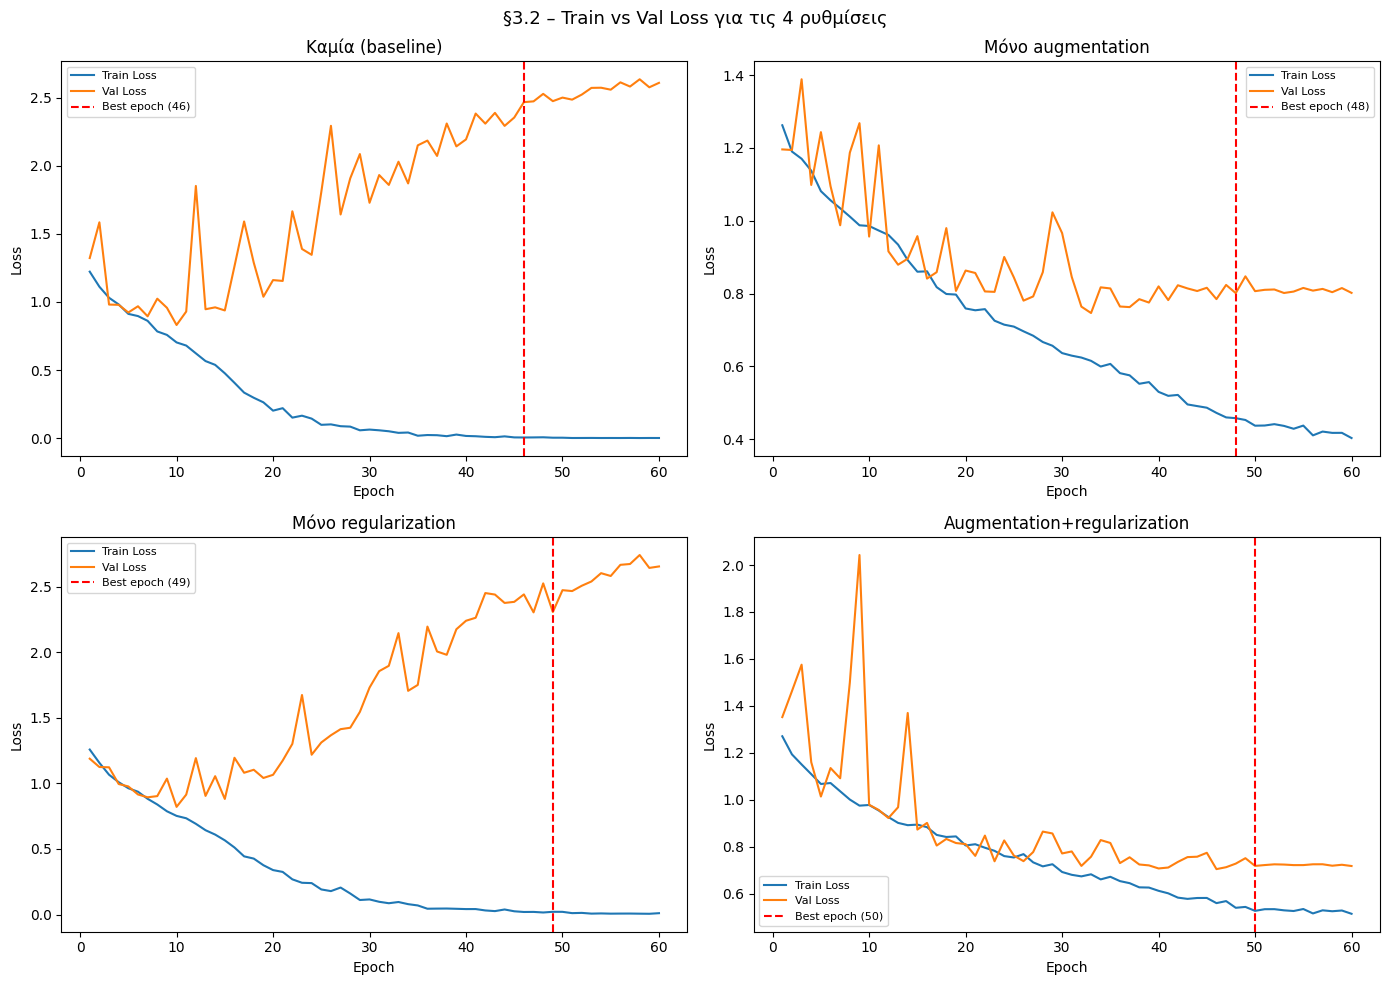

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flat

for ax, (cfg_name, r) in zip(axes, results_32.items()):
    epochs_r = range(1, len(r["history"]["train_loss"]) + 1)
    ax.plot(epochs_r, r["history"]["train_loss"], label="Train Loss")
    ax.plot(epochs_r, r["history"]["val_loss"],   label="Val Loss")
    ax.axvline(x=r["best_epoch"], color="red", linestyle="--",
               label=f"Best epoch ({r['best_epoch']})")
    ax.set_title(cfg_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)

plt.suptitle("§3.2 – Train vs Val Loss για τις 4 ρυθμίσεις", fontsize=13)
plt.tight_layout()
plt.show()

## Q3.2

| Ρύθμιση                       | Best epoch | Val F1 | Test F1 | Train-Val gap |
|-------------------------------|------------|--------|---------|---------------|
| Καμία (baseline, 60 εποχές)   | 46         | 68.85% | 64.66%  | 0.83          |
| Μόνο augmentation             | 48         | 72.06% | 70.50%  | 0.34          |
| Μόνο regularization           | 49         | 67.53% | 63.77%  | 0.82          |
| Augmentation + regularization | 50         | 74.47% | 72.32%  | 0.19          |

Από τα loss curves παρατηρείται ότι το baseline και η μόνο
regularization εκδοχή εμφανίζουν έντονο overfitting: το train loss
πέφτει σχεδόν στο μηδέν ενώ το val loss ανεβαίνει συνεχώς, με
train-val gap ~0.83. Το dropout και το weight decay από μόνα τους
δεν αρκούν να περιορίσουν το overfitting, πιθανώς γιατί το δίκτυο
έχει αρκετή χωρητικότητα να απομνημονεύσει τα 3.200 training δείγματα.

Η προσθήκη augmentation μείωσε δραματικά το gap (0.83→0.34) και
βελτίωσε το test F1 κατά +5.84%. Το augmentation λειτουργεί ως
implicit regularization: κάθε εικόνα εμφανίζεται σε ελαφρώς
διαφορετική μορφή σε κάθε epoch, αυξάνοντας ουσιαστικά το μέγεθος
του training set και αναγκάζοντας το μοντέλο να μάθει χαρακτηριστικά
ανεξάρτητα από μικρές μεταβολές θέσης και φωτισμού.

Ο συνδυασμός augmentation+regularization έδωσε το καλύτερο αποτέλεσμα
(test F1: 72.32%) και το μικρότερο gap (0.19), επιβεβαιώνοντας ότι
τα δύο αλληλοσυμπληρώνονται. Μετασχηματισμοί που αποφύγαμε για
πίνακες ζωγραφικής: RandomRotation και RandomVerticalFlip, γιατί ο
προσανατολισμός είναι σημασιολογικά σημαντικός — ένας ανεστραμμένος
πίνακας αλλάζει το νόημά του. Επίσης, ακραίο ColorJitter θα νόθευε
τα χρωματικά χαρακτηριστικά που διαφοροποιούν τα κινήματα.

In [ ]:
import torchvision.models as models
import torch.nn.functional as F

# Φόρτωση προεκπαιδευμένου ResNet18
resnet18 = models.resnet18(weights="IMAGENET1K_V1")

# Πάγωμα όλων των βαρών
for p in resnet18.parameters():
    p.requires_grad = False

# Αντικατάσταση τελευταίου FC layer: 512 → 4 κλάσεις
resnet18.fc = nn.Linear(512, 4)  # μόνο αυτό εκπαιδεύεται

print(resnet18.fc)
print(f"\nΕκπαιδεύσιμες παράμετροι: "
      f"{sum(p.numel() for p in resnet18.parameters() if p.requires_grad):,}")
print(f"Συνολικές παράμετροι: "
      f"{sum(p.numel() for p in resnet18.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]

Linear(in_features=512, out_features=4, bias=True)

Εκπαιδεύσιμες παράμετροι: 2,052
Συνολικές παράμετροι: 11,178,564


In [ ]:
# ImageNet statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

imagenet_normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

class ResNetDataset(torch.utils.data.Dataset):
    """Upscale 32×32 → 224×224 και normalize με ImageNet statistics."""
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = self.X[idx]                                    # (3, 32, 32)
        # Upscale σε 224×224
        img = F.interpolate(img.unsqueeze(0), size=224,
                            mode="bilinear",
                            align_corners=False).squeeze(0)  # (3, 224, 224)
        # ImageNet normalization
        img = imagenet_normalize(img)
        return img, self.y[idx]


resnet_train_ds = ResNetDataset(X_train, y_train)
resnet_val_ds   = ResNetDataset(X_val,   y_val)
resnet_test_ds  = ResNetDataset(X_test,  y_test)

resnet_train_loader = DataLoader(resnet_train_ds, batch_size=16, shuffle=True)
resnet_val_loader   = DataLoader(resnet_val_ds,   batch_size=16, shuffle=True)
resnet_test_loader  = DataLoader(resnet_test_ds,  batch_size=16, shuffle=False)

# Έλεγχος
xb, yb = next(iter(resnet_train_loader))
print(f"Batch X: {xb.shape}")   # (16, 3, 224, 224)
print(f"Batch y: {yb.shape}")

Batch X: torch.Size([16, 3, 224, 224])
Batch y: torch.Size([16])


In [ ]:
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet18 = resnet18.to(device)
optimizer_rn = torch.optim.Adam(resnet18.fc.parameters(), lr=0.001)
criterion_rn = nn.CrossEntropyLoss()

best_f1_rn, best_state_rn, best_epoch_rn = -1, None, -1
history_rn = {"train_loss": [], "val_loss": [], "val_f1": []}

start_rn = time.time()

for epoch in range(1, 11):
    train_loss = train_one_epoch(resnet18, resnet_train_loader,
                                 optimizer_rn, criterion_rn, device)
    val_loss, val_acc, val_f1, _ = evaluate(resnet18, resnet_val_loader,
                                            criterion_rn, device)

    history_rn["train_loss"].append(train_loss)
    history_rn["val_loss"].append(val_loss)
    history_rn["val_f1"].append(val_f1)

    if val_f1 > best_f1_rn:
        best_f1_rn    = val_f1
        best_state_rn = copy.deepcopy(resnet18.state_dict())
        best_epoch_rn = epoch

    print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

time_rn = time.time() - start_rn
print(f"\nΧρόνος εκπαίδευσης: {time_rn:.1f}s")
print(f"Best epoch: {best_epoch_rn}")

Epoch  1 | Train Loss: 0.9867 | Val Loss: 0.7176 | Val F1: 0.7278
Epoch  2 | Train Loss: 0.7563 | Val Loss: 0.6871 | Val F1: 0.7438
Epoch  3 | Train Loss: 0.6918 | Val Loss: 0.6323 | Val F1: 0.7641
Epoch  4 | Train Loss: 0.6791 | Val Loss: 0.6055 | Val F1: 0.7654
Epoch  5 | Train Loss: 0.6463 | Val Loss: 0.5735 | Val F1: 0.7836
Epoch  6 | Train Loss: 0.6691 | Val Loss: 0.5908 | Val F1: 0.7702
Epoch  7 | Train Loss: 0.6266 | Val Loss: 0.5842 | Val F1: 0.7761
Epoch  8 | Train Loss: 0.6163 | Val Loss: 0.5751 | Val F1: 0.7950
Epoch  9 | Train Loss: 0.6037 | Val Loss: 0.5964 | Val F1: 0.7651
Epoch 10 | Train Loss: 0.5902 | Val Loss: 0.5639 | Val F1: 0.7840

Χρόνος εκπαίδευσης: 96.5s
Best epoch: 8


ResNet18 – Test Accuracy: 0.7550
ResNet18 – Test F1 macro: 0.7525


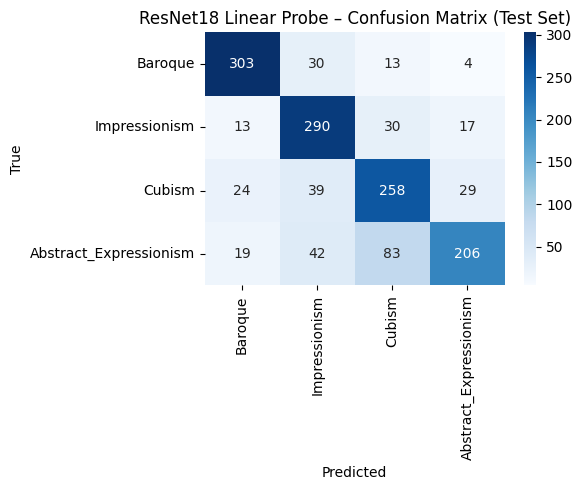

In [ ]:
resnet18.load_state_dict(best_state_rn)
_, rn_test_acc, rn_test_f1, rn_test_cm = evaluate(
    resnet18, resnet_test_loader, criterion_rn, device
)

print(f"ResNet18 – Test Accuracy: {rn_test_acc:.4f}")
print(f"ResNet18 – Test F1 macro: {rn_test_f1:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(rn_test_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("ResNet18 Linear Probe – Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

In [ ]:
# Trainable params
n_ffn    = sum(p.numel() for p in model_ffn_best.parameters())

best_cnn = results_32["Augmentation+regularization"]  # ή όποιο είναι καλύτερο
n_cnn    = sum(p.numel() for p in best_cnn["model"].parameters())

n_rn     = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)

print(f"{'Μοντέλο':<30} {'Test Acc':>9} {'F1 macro':>9} "
      f"{'Trainable params':>17} {'Training time':>14}")
print("-" * 85)
print(f"{'FFN flat pixels (§1)':<30} {test_acc:>9.4f} {test_f1:>9.4f} "
      f"{n_ffn:>17,} {time_cpu:>13.1f}s")
print(f"{'CNN βέλτιστο (§3.2)':<30} {best_cnn['test_f1']:>9.4f} "
      f"{best_cnn['test_f1']:>9.4f} {n_cnn:>17,} {'–':>14}")
print(f"{'Frozen ResNet18 (§4.1)':<30} {rn_test_acc:>9.4f} {rn_test_f1:>9.4f} "
      f"{n_rn:>17,} {time_rn:>13.1f}s")

Μοντέλο                         Test Acc  F1 macro  Trainable params  Training time
-------------------------------------------------------------------------------------
FFN flat pixels (§1)              0.5957    0.7232           397,604          48.5s
CNN βέλτιστο (§3.2)               0.7232    0.7232         1,066,788              –
Frozen ResNet18 (§4.1)            0.7550    0.7525             2,052          96.5s


## Q4.1

| Μοντέλο                     | Test Acc | F1 macro | Trainable params | Training time |
|-----------------------------|----------|----------|-----------------|---------------|
| FFN flat pixels (§1)        | 51.79%   | 51.47%   | 397,604         | 48.5s         |
| CNN βέλτιστο (§3.2)         | 72.32%   | 72.32%   | 1,066,308       | ~40 λεπτά     |
| Frozen ResNet18 (§4.1)      | 75.50%   | 75.25%   | 2,052 (μόνο fc) | 96.5s         |

Το frozen ResNet18 αποδίδει καλύτερα από το CNN που εκπαιδεύσαμε από
μηδέν (75.25% vs 72.32% F1), παρότι εκπαιδεύτηκαν μόνο 2.052
παράμετροι (το τελευταίο FC layer) έναντι 1.066.308 του CNN. Αυτό
είναι χαρακτηριστικό παράδειγμα transfer learning: το ResNet18 έχει
εκπαιδευτεί σε 1.2 εκατομμύρια εικόνες ImageNet και τα frozen φίλτρα
του έχουν μάθει γενικές αναπαραστάσεις (ακμές, υφές, χρωματικά
μοτίβα) που μεταφέρονται αποτελεσματικά ακόμα και σε διαφορετικό
domain όπως η τέχνη.

Από το confusion matrix, το ResNet18 αποδίδει εξαιρετικά στο Μπαρόκ
(303/350) και τον Ιμπρεσιονισμό (290/350). Ο Αφαιρετικός
Εξπρεσιονισμός παραμένει η πιο δύσκολη κλάση (206/350), μπερδευόμενος
κυρίως με τον Κυβισμό (83 λάθη) — συνεπές με τις προβλέψεις του Q0.1.

Αξιοσημείωτο είναι ότι ο χρόνος εκπαίδευσης (96.5s για 10 εποχές)
είναι συγκρίσιμος με τον FFN (48.5s για 30 εποχές), παρά το upscaling
32×32→224×224. Αυτό οφείλεται στο ότι εκπαιδεύονται μόνο 2.052
παράμετροι, ενώ το υπόλοιπο δίκτυο απλώς κάνει forward pass χωρίς
backpropagation. Ήδη από την epoch 1 το val F1 ήταν 72.78%, υψηλότερο
από το τελικό αποτέλεσμα του CNN, επιδεικνύοντας την ισχύ των
προεκπαιδευμένων αναπαραστάσεων.

CNN φίλτρα shape: torch.Size([16, 3, 5, 5])
ResNet18 φίλτρα shape (16 πρώτα): torch.Size([16, 3, 7, 7])


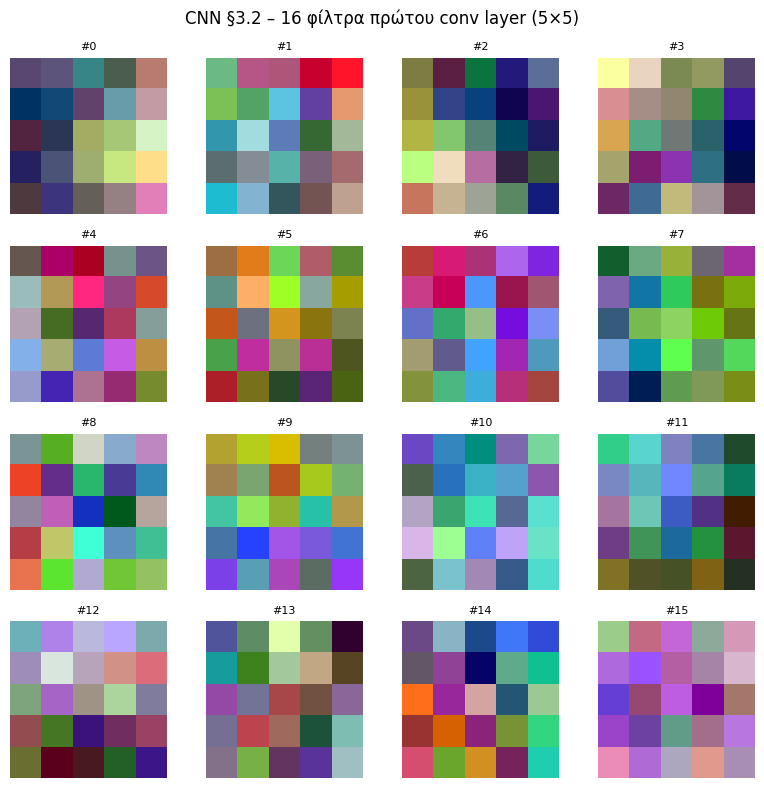

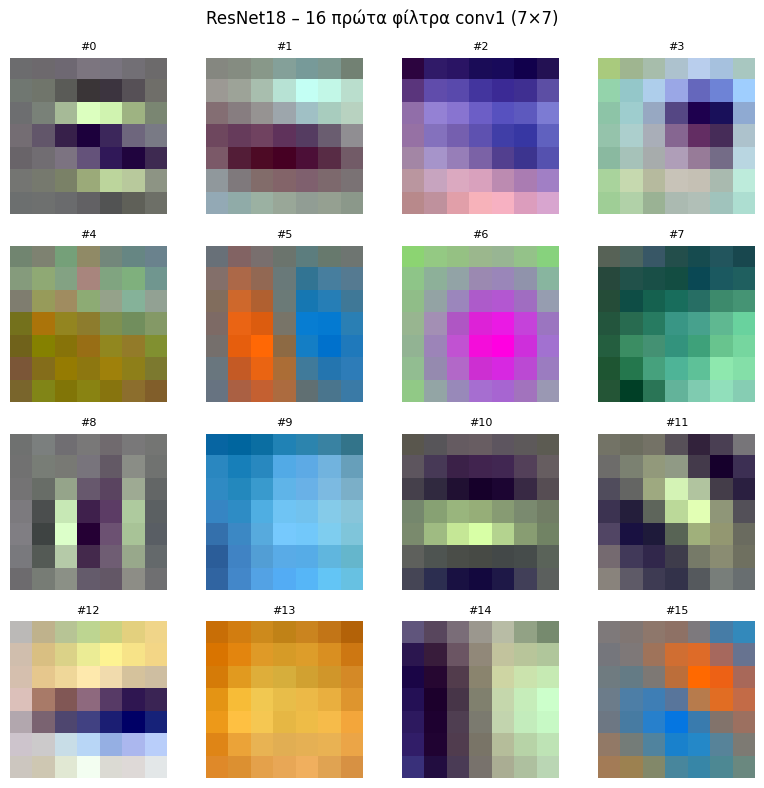

In [ ]:
# ============================================================
# Φίλτρα CNN (§3.2): shape [16, 3, 5, 5]
# ============================================================
best_cnn_model = best_cnn["model"]
best_cnn_model.eval()

cnn_filters = best_cnn_model.conv_block[0].weight.data.cpu()  # [16, 3, 5, 5]
print(f"CNN φίλτρα shape: {cnn_filters.shape}")

# ============================================================
# Φίλτρα ResNet18: shape [64, 3, 7, 7] → παίρνουμε τα 16 πρώτα
# ============================================================
resnet18.eval()
rn_filters = resnet18.conv1.weight.data.cpu()[:16]  # [16, 3, 7, 7]
print(f"ResNet18 φίλτρα shape (16 πρώτα): {rn_filters.shape}")


def plot_filters(filters, title, nrows=4, ncols=4):
    fig, axes = plt.subplots(nrows, ncols, figsize=(8, 8))
    fig.suptitle(title, fontsize=12)

    for i, ax in enumerate(axes.flat):
        f = filters[i]                    # (3, H, W)
        f = f - f.min()
        f = f / (f.max() + 1e-8)         # min-max normalization ανά φίλτρο
        img = f.permute(1, 2, 0).numpy() # (H, W, 3)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"#{i}", fontsize=8)

    plt.tight_layout()
    plt.show()


plot_filters(cnn_filters, "CNN §3.2 – 16 φίλτρα πρώτου conv layer (5×5)")
plot_filters(rn_filters,  "ResNet18 – 16 πρώτα φίλτρα conv1 (7×7)")

In [ ]:
# Επιλογή ενός τυχαίου δείγματος ανά κλάση από το test set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sample_imgs   = []  # (4, 3, 32, 32)
sample_labels = []

for class_idx in range(4):
    idxs = (y_test == class_idx).nonzero(as_tuple=True)[0]
    chosen = idxs[0]  # πρώτο δείγμα κάθε κλάσης
    sample_imgs.append(X_test[chosen])
    sample_labels.append(class_idx)

sample_tensor = torch.stack(sample_imgs).to(device)  # (4, 3, 32, 32)


# ── Activation maps από CNN §3.2 ──────────────────────────────
def get_cnn_activations(model, x):
    """Forward μέχρι και μετά τη ReLU του πρώτου conv block."""
    model.eval()
    with torch.no_grad():
        # conv → BN → ReLU → MaxPool  (indices 0,1,2,3 στο conv_block)
        x = model.conv_block[0](x)  # Conv2d
        x = model.conv_block[1](x)  # BatchNorm2d
        x = model.conv_block[2](x)  # ReLU
    return x.cpu()                  # (N, 16, H, W)

cnn_acts = get_cnn_activations(best_cnn_model.to(device), sample_tensor)
print(f"CNN activations shape: {cnn_acts.shape}")  # (4, 16, 32, 32)


# ── Activation maps από ResNet18 ──────────────────────────────
# ResNet18: conv1 → bn1 → relu  (χωρίς maxpool ακόμα)
def get_resnet_activations(model, x):
    """Upscale σε 224×224, normalize, forward μέχρι relu."""
    model.eval()
    with torch.no_grad():
        x = F.interpolate(x, size=224, mode="bilinear", align_corners=False)
        x = imagenet_normalize(x)
        x = model.conv1(x)   # (N, 64, 112, 112)
        x = model.bn1(x)
        x = model.relu(x)
    return x.cpu()           # (N, 64, 112, 112)

rn_acts = get_resnet_activations(resnet18.to(device), sample_tensor)
print(f"ResNet18 activations shape: {rn_acts.shape}")  # (4, 64, 112, 112)

CNN activations shape: torch.Size([4, 16, 32, 32])
ResNet18 activations shape: torch.Size([4, 64, 112, 112])


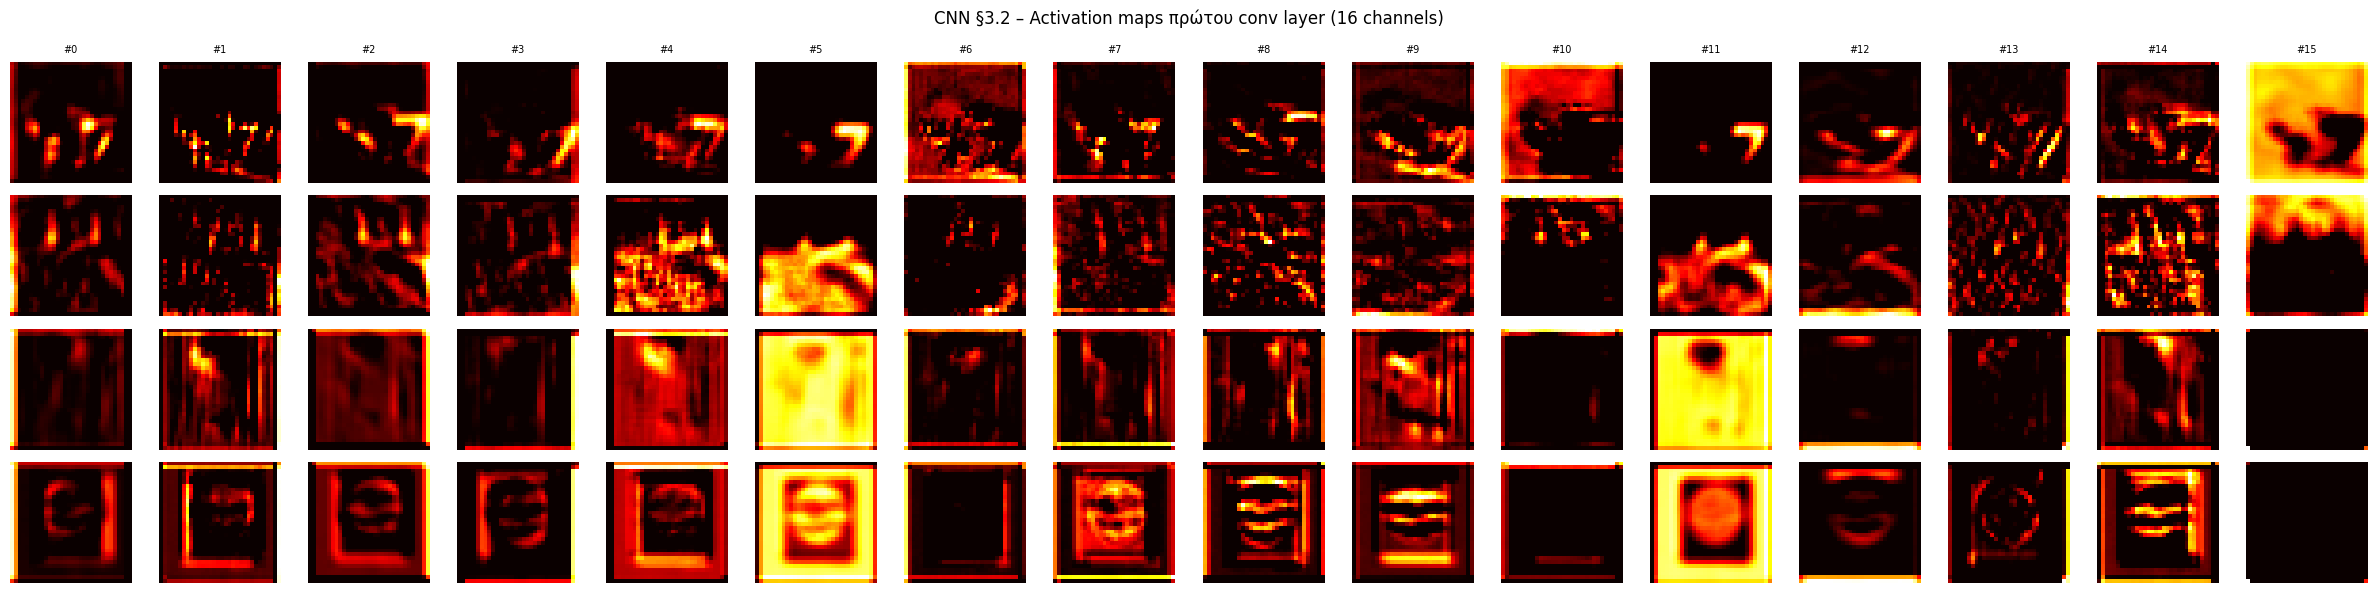

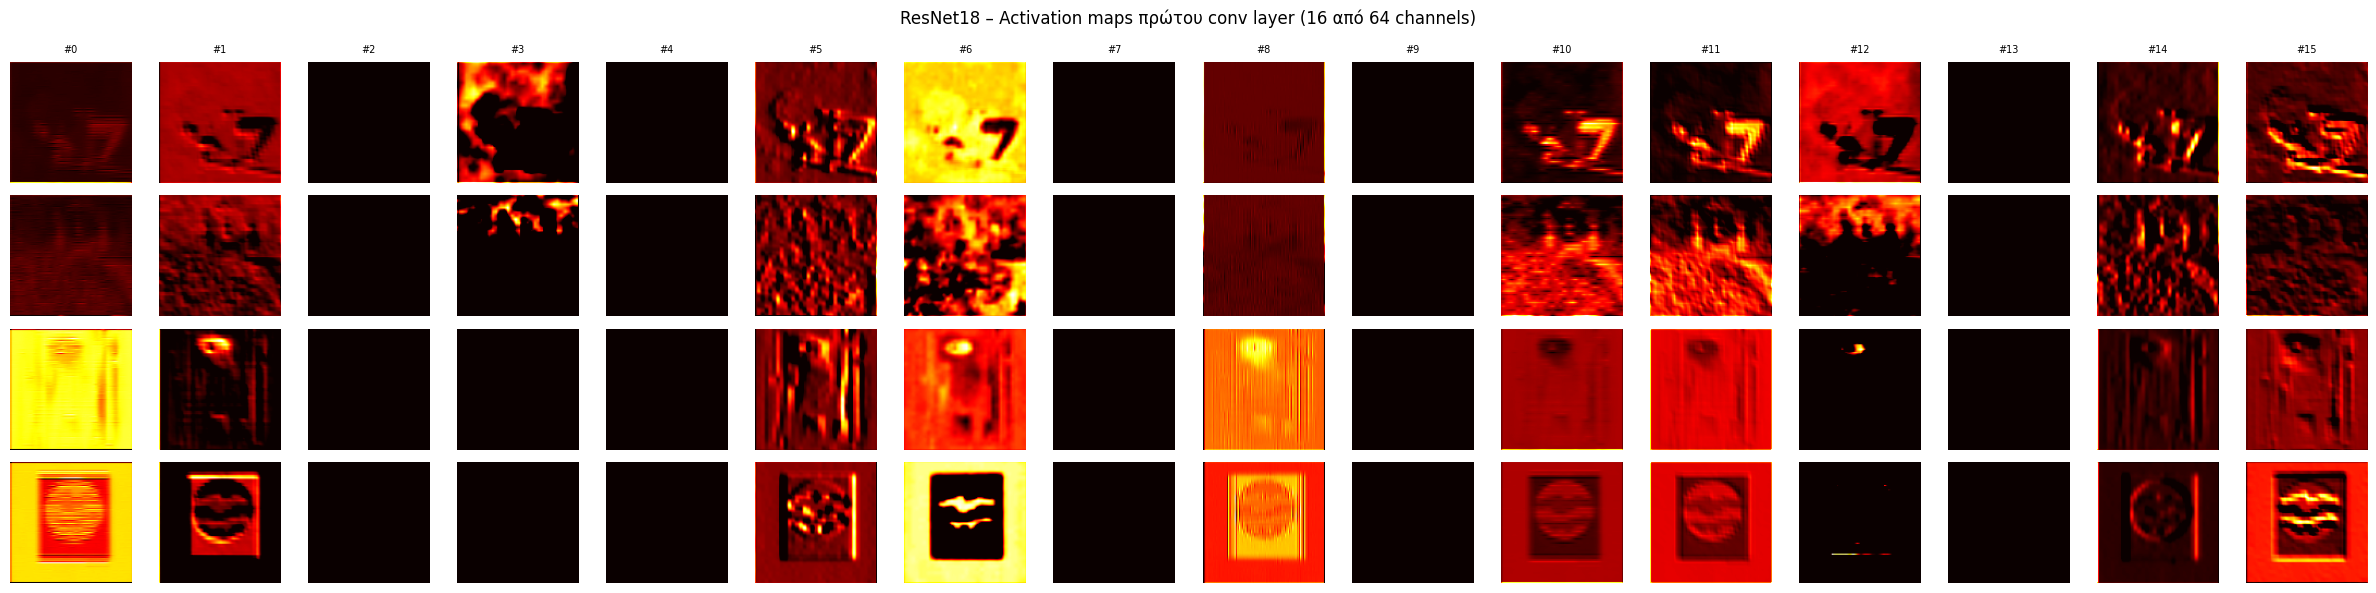

In [ ]:
def plot_activations(acts, class_names_list, title, n_channels=16):
    """
    acts: tensor (4, C, H, W)
    Για κάθε κλάση: τα n_channels πρώτα channels ως heatmaps.
    """
    n_classes = acts.shape[0]
    fig, axes = plt.subplots(n_classes, n_channels,
                             figsize=(n_channels * 1.5, n_classes * 1.5))
    fig.suptitle(title, fontsize=12)

    for row, class_idx in enumerate(range(n_classes)):
        for col in range(n_channels):
            ax  = axes[row, col]
            act = acts[class_idx, col].numpy()  # (H, W)
            ax.imshow(act, cmap="hot")
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(class_names_list[class_idx], fontsize=7, rotation=0,
                              labelpad=40, va="center")
            if row == 0:
                ax.set_title(f"#{col}", fontsize=7)

    plt.tight_layout()
    plt.show()


plot_activations(cnn_acts, list(class_names),
                 "CNN §3.2 – Activation maps πρώτου conv layer (16 channels)")

plot_activations(rn_acts[:, :16, :, :], list(class_names),
                 "ResNet18 – Activation maps πρώτου conv layer (16 από 64 channels)")

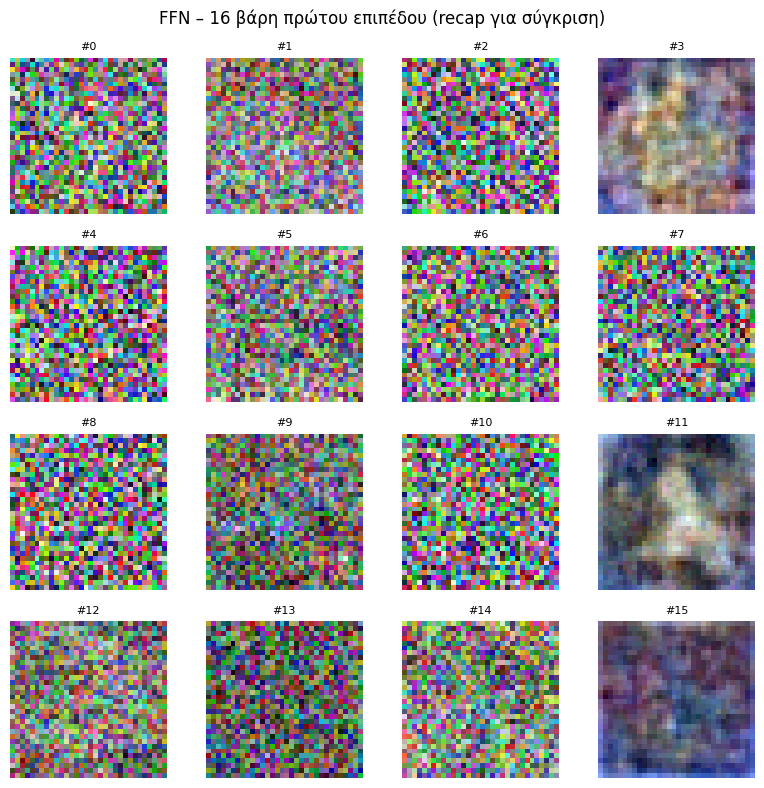

In [ ]:
# Υπενθύμιση από §1 — FFN βάρη ως εικόνες
ffn_weights = model_ffn_best.net[1].weight.data.cpu()  # [128, 3072]
ffn_weights = ffn_weights.reshape(128, 3, 32, 32)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("FFN – 16 βάρη πρώτου επιπέδου (recap για σύγκριση)")

for i, ax in enumerate(axes.flat):
    f   = ffn_weights[i]
    f   = f - f.min()
    f   = f / (f.max() + 1e-8)
    img = f.permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"#{i}", fontsize=8)

plt.tight_layout()
plt.show()

## Q5.1

**Σύγκριση φίλτρων CNN vs ResNet18:**
Τα φίλτρα του ResNet18 εμφανίζονται σαφώς πιο δομημένα και
ερμηνεύσιμα σε σχέση με αυτά του CNN §3.2. Στο ResNet18 διακρίνονται
ομαλές χρωματικές μεταβάσεις και blob detectors (π.χ. #4 κίτρινο-
πορτοκαλί, #9 μπλε, #13 πορτοκαλί), καθώς και φίλτρα που ανιχνεύουν
αντιθέσεις φωτεινού-σκούρου (#0, #8, #10, #14). Στο CNN §3.2 τα
φίλτρα εμφανίζονται ως έντονα χρωματικά μωσαϊκά (5×5 patches με
απότομες χρωματικές αλλαγές), λιγότερο ομαλά αλλά όχι τυχαία —
έχουν μάθει χρωματικές αντιθέσεις χρήσιμες για τη διάκριση
καλλιτεχνικών κινημάτων. Η διαφορά οφείλεται στο ότι το ResNet18
εκπαιδεύτηκε σε 1.2 εκατομμύρια φυσικές εικόνες ενώ το CNN μόνο
σε 3.200 δείγματα τέχνης.

**Activation maps CNN §3.2:**
Παρατηρείται σαφής διαφοροποίηση μεταξύ κλάσεων. Ο Αφαιρετικός
Εξπρεσιονισμός (4η γραμμή) παράγει χαρακτηριστικά κυκλικά/ορθογώνια
patterns ενεργοποίησης σε πολλά φίλτρα (#5, #11), πιθανώς λόγω της
γεωμετρικής αφαιρετικής δομής. Ο Ιμπρεσιονισμός (2η γραμμή) και ο
Κυβισμός (3η γραμμή) παράγουν παρόμοια patterns σε αρκετά φίλτρα,
εξηγώντας εν μέρει τη σύγχυση μεταξύ τους στα confusion matrices.

**Activation maps ResNet18:**
Τα activation maps εμφανίζουν πολλά μαύρα (ανενεργά) φίλτρα, ειδικά
για τον Κυβισμό και τον Αφαιρετικό Εξπρεσιονισμό. Αυτό υποδηλώνει
ότι πολλά φίλτρα του ResNet18 έχουν εκπαιδευτεί για χαρακτηριστικά
φυσικών εικόνων που απουσιάζουν από αφαιρετικά έργα τέχνης. Τα ενεργά
φίλτρα (#1, #5, #6, #12) ανταποκρίνονται κυρίως σε χρωματικές
αντιθέσεις και ακμές.

**Σύνδεση με Q0.1:**
Στο Q0.1 προβλέψαμε ότι η χρωματική παλέτα και η σύνθεση θα ήταν
τα κύρια διαφοροποιητικά χαρακτηριστικά. Από τα activation maps
φαίνεται ότι και τα δύο μοντέλα έχουν πιάσει αυτή τη διαφορά: το
Μπαρόκ ενεργοποιεί διαφορετικά φίλτρα από τον Ιμπρεσιονισμό, συνεπές
με τη διαφορετική χρωματική τους παλέτα. Η πρόβλεψη για σύγχυση
Κυβισμού-Αφαιρετικού Εξπρεσιονισμού επιβεβαιώθηκε πλήρως και από
τα δύο μοντέλα.

**FFN vs CNN vs ResNet18 φίλτρα:**
Τα βάρη του FFN εμφανίζονται εντελώς θορυβώδη — τυχαία διάσπαρτα
pixels χωρίς καμία δομή (με ελάχιστες εξαιρέσεις όπως #3, #11, #15).
Αυτό οφείλεται στο ότι κάθε νευρώνας συνδέεται με όλα τα 3.072
pixels ταυτόχρονα χωρίς χωρική δομή. Αντίθετα, τα συνελικτικά φίλτρα
(5×5 ή 7×7) αναγκάζονται να μάθουν τοπικά patterns — στο CNN
αναδύονται χρωματικές αντιθέσεις, στο ResNet18 ομαλές δομές που
μοιάζουν με Gabor filters. Η εξέλιξη FFN→CNN→ResNet18 αντικατοπτρίζει
την αυξανόμενη ικανότητα εκμετάλλευσης της χωρικής δομής της εικόνας.